<a href="https://colab.research.google.com/github/dangchicong/hocsau/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bước 1: Chuẩn bị thư viện cho bài thực hành;
Import thư viện tính toán số;
Import thư viện xử lý dữ liệu;
Import công cụ chia dữ liệu;
Import mô hình Linear Regression;
Import hàm đánh giá mô hình;
Import thư viện vẽ biểu đồ.

In [1]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


Bước 1b: Dùng Pandas để tải file CSV từ GitHub và lưu vào biến df dưới dạng bảng dữ liệu (DataFrame).

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/dangchicong/hocsau/refs/heads/main/04_CIGARET.csv")

Bước 1c: Hiển thị 5 dòng đầu tiên của bảng dữ liệu DataFrame.

In [3]:
df.head()

,KgTar,KgNic,KgCO,MnTar,MnNic,MnCO,FLTar,FLNic,FLCO
0,20,1.1,16,16,1.1,15,5,0.4,4
1,27,1.7,16,13,0.8,17,16,1.0,19
2,27,1.7,16,16,1.0,19,17,1.2,17
3,20,1.1,16,9,0.9,9,13,0.8,18
4,20,1.1,16,14,0.8,17,13,0.8,18


Bước 2: Chọn 2 cột KgNic, KgCO làm biến đầu vào; cột dự đoán KgTar dựa trên KgNic, KgCO

In [4]:
X = df[['KgNic', 'KgCO']]
y = df['KgTar']

Bước 3: Chia dữ liệu thành 2 phần: dữ liệu huấn luyện và dữ liệu kiểm tra trong bài toán Linear Regression (20% làm dữ liệu test).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Bước 4: Huấn luyện mô hình hồi quy tuyến tính; 1/ tạo một mô hình hồi quy tuyến tính từ thư viện Scikit-learn.; 2/ Huấn luyện: Cho mô hình học mối quan hệ giữa X và y từ dữ liệu train; 3/ công thức: KgTar=a.KgNic+b.KgCO+c (c: hệ số chặn)

In [6]:
# TODO: Train your model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Bước 4b:Dự đoán giá trị y (KgTar) từ dữ liệu đầu vào X_test; y_pred = model.predict(X_test)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# TODO: Make predictions
y_pred = model.predict(X_test)

Bước 5: Đánh giá mô hình Vadidation

In [16]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

MSE: 1.3001985691242197
R2: 0.49210993393585156


Bước 5b: So sánh dự đoán và thực tế

In [13]:
import pandas as pd

result = pd.DataFrame({
    "Thực tế": y_test,
    "Dự đoán": y_pred
})

print(result.head())

    Thực tế    Dự đoán
8        20  20.846459
16       24  22.640510
0        20  21.145467
23       20  21.145467
11       20  21.145467


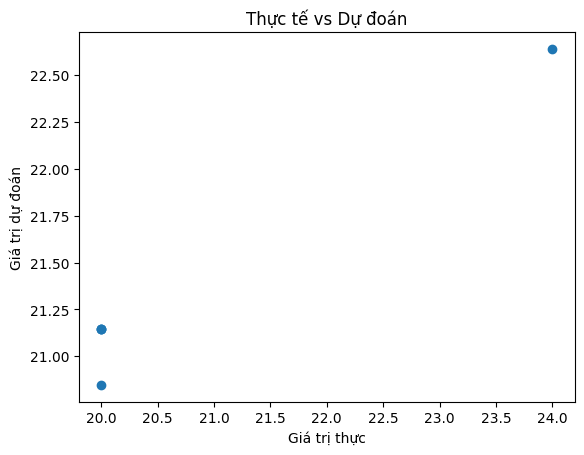

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Giá trị thực")
plt.ylabel("Giá trị dự đoán")
plt.title("Thực tế vs Dự đoán")
plt.show()